## 1. Učitavanje podataka

U ovom notebooku provodi se klasteriranje Airbnb smještaja. Klasteriranje je metoda nenadziranog učenja, što znači da model nema ciljnu varijablu koju predviđa, nego sam pokušava pronaći prirodne skupine sličnih smještaja u podacima.

In [3]:
from google.colab import files

uploaded = files.upload()

Saving airbnb_features.csv to airbnb_features.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("airbnb_features.csv")
df.head()

,id,name,host_id,host_identity_verified,host_name,neighbourhood_group,neighbourhood,lat,long,country,...,professional_host,neighborhood_avg_price,price_diff_neighborhood,distance_to_center,popularity_score,luxury_listing,high_price,room_type_encoded,neighbourhood_group_encoded,cancellation_policy_encoded
0,1001254,Clean & quiet apt home by the park,8.001449e+10,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,1,519.519337,446.480663,12.337898,-0.469815,0,1,2,1,2
1,1002102,Skylit Midtown Castle,5.233517e+10,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,0,521.095921,-379.095921,0.508366,0.321559,0,0,0,2,1
2,1002755,Water View King Bed Hotel Room,8.509833e+10,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,0,528.641953,-160.641953,8.387034,7.147646,0,0,0,1,1
3,1004650,BlissArtsSpace!,6.130061e+10,unconfirmed,Alberta,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,United States,...,0,526.145253,-455.145253,8.290747,1.198536,0,0,2,1,1
4,1006859,Cute & Cozy Lower East Side 1 bdrm,1.280143e+09,verified,Miranda,Manhattan,Chinatown,40.71344,-73.99037,United States,...,0,516.832061,-197.832061,4.971807,2.300431,0,0,0,2,0


## 2. Ideja klasteriranja

Kako je klasteriranje je zadatak nenadziranog učenja, ovdje ne postoji ciljna varijabla poput `high_price`.

Cilj je pronaći skupine smještaja koje su međusobno slične prema odabranim atributima.

U ovom radu želimo otkriti postoje li različiti tipovi Airbnb smještaja, primjerice luksuzni smještaji, popularni turistički smještaji, povoljniji smještaji ili manje popularni udaljeni smještaji.

## 3. Odabir atributa

Za klasteriranje su odabrani atributi koji opisuju ekonomsku, lokacijsku i korisničku dimenziju smještaja.

Korišteni su:

- `price` — cijena smještaja,
- `distance_to_center` — udaljenost od centra grada,
- `popularity_score` — izvedena mjera popularnosti,
- `availability_ratio` — udio dostupnosti tijekom godine,
- `review_rate_number` — ocjena smještaja.

Ovi atributi zajedno omogućuju grupiranje smještaja prema cijeni, lokaciji, popularnosti i dostupnosti.

In [6]:
cluster_features = [
    "price",
    "distance_to_center",
    "popularity_score",
    "availability_ratio",
    "review_rate_number"
]

X_cluster = df[cluster_features].copy()
X_cluster.head()

,price,distance_to_center,popularity_score,availability_ratio,review_rate_number
0,966.0,12.337898,-0.469815,0.783562,4.0
1,142.0,0.508366,0.321559,0.624658,4.0
2,368.0,8.387034,7.147646,0.882192,4.0
3,71.0,8.290747,1.198536,0.613699,5.0
4,319.0,4.971807,2.300431,0.002740,3.0


In [7]:
X_cluster.isnull().sum()

,0
price,0
distance_to_center,0
popularity_score,0
availability_ratio,0
review_rate_number,0


In [8]:
X_cluster = X_cluster.fillna(0)

## 4. Skaliranje podataka

K-Means algoritam koristi udaljenosti između točaka. Zbog toga je važno da atributi budu na usporedivim skalama.

Primjerice, cijena može imati vrijednosti od nekoliko desetaka do više stotina dolara, dok je `availability_ratio` između 0 i 1. Bez skaliranja bi atributi s većim numeričkim vrijednostima imali prevelik utjecaj na klasteriranje.

Zato koristimo standardizaciju podataka.

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

## 5. Formiranje klastera

Početni centroidi nisu određeni ručno, već je korištena metoda `k-means++`, koja odabire početne centre na način da budu međusobno udaljeni te time poboljšava stabilnost algoritma.

Parametar `n_init=10` omogućuje izvođenje algoritma deset puta s različitim početnim centroidima, nakon čega se zadržava najbolje rješenje.

## 6. Odabir broja klastera

K-Means algoritam zahtijeva unaprijed definiranje broja klastera K.

Kako bi se odredio optimalan broj klastera, korišteni je Calinski-Harabasz indeks. Alternativno, pokušan je i koef. siluete (međutim jako je spor).



Calinski-Harabasz indeks procjenjuje kvalitetu klasteriranja usporedbom:

- razdvojenosti klastera
- zbijenosti klastera

Veće vrijednosti indeksa označavaju kvalitetnije klasteriranje.

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score

ch_scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = calinski_harabasz_score(
        X_scaled,
        labels
    )

    ch_scores.append(score)

    print(f"K={k}: {score:.2f}")

K=2: 13306.55
K=3: 11547.18
K=4: 10830.72
K=5: 10344.71
K=6: 10131.63
K=7: 9981.79
K=8: 9905.03
K=9: 9532.80
K=10: 9050.70


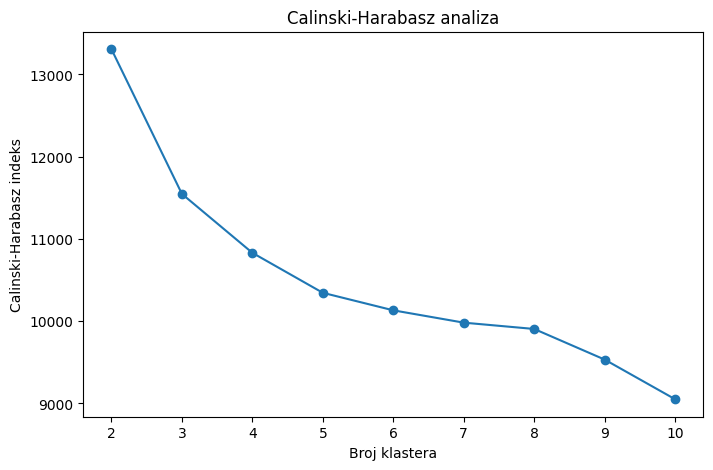

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    ch_scores,
    marker="o"
)

plt.xlabel("Broj klastera")
plt.ylabel("Calinski-Harabasz indeks")
plt.title("Calinski-Harabasz analiza")

plt.show()

Na temelju Calinski-Harabasz indeksa najveća vrijednost postignuta je za K=2.

Stoga su za daljnju analizu odabrana dva klastera.

In [13]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_scaled)
df["cluster"].value_counts()

,count
cluster,
0,26523
1,24522


In [14]:
cluster_summary = df.groupby("cluster").mean(numeric_only=True)
cluster_summary

,id,host_id,lat,long,instant_bookable,construction_year,price,service_fee,minimum_nights,number_of_reviews,...,professional_host,neighborhood_avg_price,price_diff_neighborhood,distance_to_center,popularity_score,luxury_listing,high_price,room_type_encoded,neighbourhood_group_encoded,cancellation_policy_encoded
cluster,,,,,,,,,,,,,,,,,,,,,
0,3.031710e+07,4.942024e+10,40.728016,-73.947734,0.498586,2012.571126,528.691588,105.778042,7.963579,37.818007,...,0.157788,525.999831,2.691758,7.544761,1.160659,0.061871,0.499529,0.957132,1.697998,0.994608
1,2.965898e+07,4.903860e+10,40.729251,-73.951556,0.498369,2012.379085,522.959547,104.621564,9.050975,18.712381,...,0.149702,525.856325,-2.896778,7.210561,-1.255369,0.000000,0.495351,0.961953,1.683753,1.004323


## 7. Interpretacija klastera

Nakon primjene K-Means algoritma s dva klastera analizirane su prosječne vrijednosti atributa unutar svakog klastera.

Rezultati pokazuju da se klasteri ne razlikuju značajno prema cijeni smještaja, budući da je prosječna cijena u oba klastera približno jednaka.

Najveće razlike uočene su u varijablama povezanim s popularnošću smještaja, kao što su broj recenzija, broj recenzija po mjesecu i `popularity_score`.

Klaster `0` obuhvaća smještaje s većim brojem recenzija i većom aktivnošću korisnika te se može interpretirati kao skup popularnijih smještaja.

Klaster `1` sadrži smještaje s manjim brojem recenzija i nižim popularity_score te predstavlja manje popularne smještaje.

Na temelju toga zaključujemo da je K-Means algoritam identificirao prirodnu podjelu smještaja prema razini popularnosti i aktivnosti korisnika, a ne prema samoj cijeni.

## 8. Vizualizacija klastera pomoću PCA

Budući da se klasteriranje provodi nad većim brojem atributa, izravna vizualizacija nije moguća.

Za prikaz rezultata koristi se metoda `PCA (Principal Component Analysis)`, koja transformira podatke u novi koordinatni sustav te zadržava što veći dio ukupne varijance.

Prve dvije glavne komponente koriste se za prikaz smještaja u dvodimenzionalnom prostoru.

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(51045, 2)


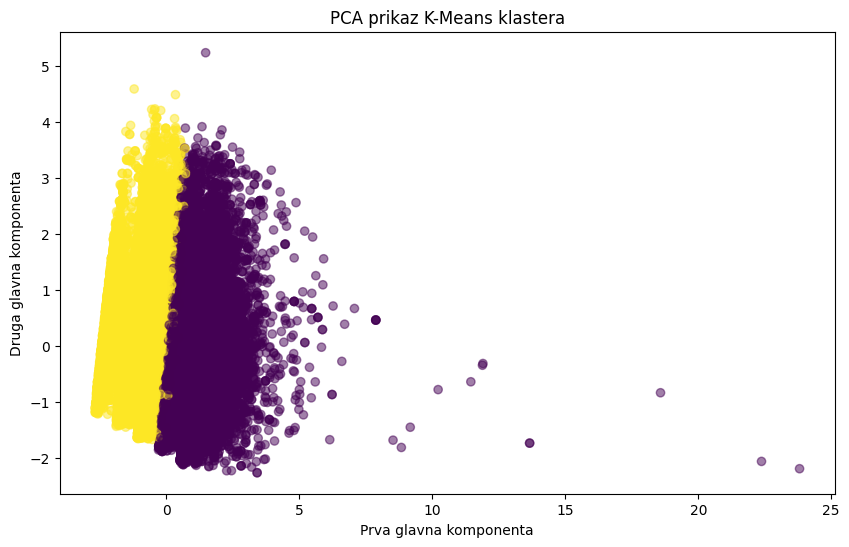

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["cluster"],
    alpha=0.5
)

plt.xlabel("Prva glavna komponenta")
plt.ylabel("Druga glavna komponenta")
plt.title("PCA prikaz K-Means klastera")

plt.show()


Na grafu se može uočiti djelomična odvojenost dvaju klastera dobivenih K-Means algoritmom. Prvi klaster formira kompaktniju skupinu podataka, dok drugi pokazuje veću raspršenost i prisutnost nekoliko ekstremnih opažanja. Rezultat potvrđuje da među smještajima postoje dvije prirodne skupine koje se prvenstveno razlikuju prema popularnosti, aktivnosti korisnika i dostupnosti smještaja.


# 9. Zaključak

Primjenom K-Means algoritma identificirane su dvije prirodne skupine Airbnb smještaja.

Optimalan broj klastera određen je pomoću Calinski–Harabasz kriterija.

Analiza klastera pokazala je da se skupine ne razlikuju značajno prema cijeni ili udaljenosti od centra grada, već prvenstveno prema popularnosti i aktivnosti korisnika.

Klaster `0` obuhvaća popularnije smještaje s većim brojem recenzija i većom aktivnošću korisnika, dok klaster `1` sadrži manje popularne smještaje.

Dobiveni rezultati pokazuju da se u promatranom skupu podataka prirodna segmentacija smještaja temelji na korisničkom interesu i aktivnosti, a ne na samoj cijeni smještaja.